
Spaceship Titanic - Machine Learning Classification

## Project Overview

This project predicts whether passengers aboard the Spaceship Titanic were transported to another dimension. The workflow includes data preprocessing, exploratory data analysis, feature engineering, model training, hyperparameter tuning, evaluation, and Kaggle submission.


In [1]:
import sys
print(sys.executable)

c:\Users\Lenovo\Documents\ML Project_Payoda\Spaceship_Titanic_Project\venv\Scripts\python.exe


 1. Import Libraries

In [3]:
import pandas as pd
print(pd.__version__)

3.0.5


 2. Load Dataset

In [4]:
import pandas as pd

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)


Train Shape: (8693, 14)
Test Shape: (4277, 13)


3. Exploratory Data Analysis (EDA)

In [6]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [8]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [9]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [10]:
train.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='str')

In [11]:
train["Transported"].value_counts()

Transported
True     4378
False    4315
Name: count, dtype: int64

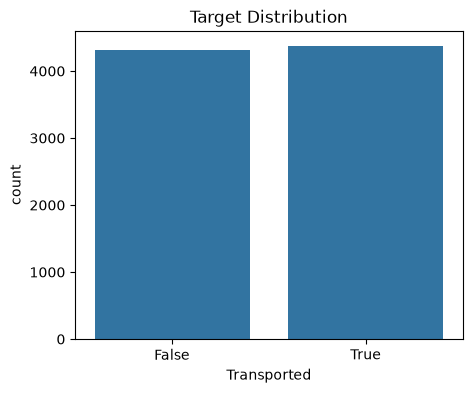

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.countplot(data=train, x="Transported")
plt.title("Target Distribution")
plt.show()

In [13]:
missing_values = train.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(train)) * 100
})

missing_df

,Missing Values,Percentage
CryoSleep,217,2.496261
ShoppingMall,208,2.392730
VIP,203,2.335212
HomePlanet,201,2.312205
Name,200,2.300702
Cabin,199,2.289198
VRDeck,188,2.162660
Spa,183,2.105142
FoodCourt,183,2.105142
Destination,182,2.093639


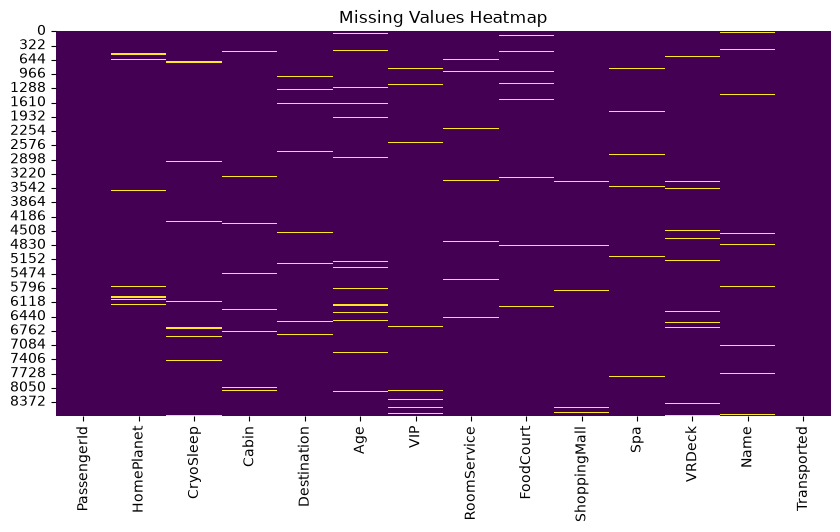

In [14]:
plt.figure(figsize=(10,5))

sns.heatmap(train.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values Heatmap")
plt.show()

In [15]:
train.dtypes

PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object

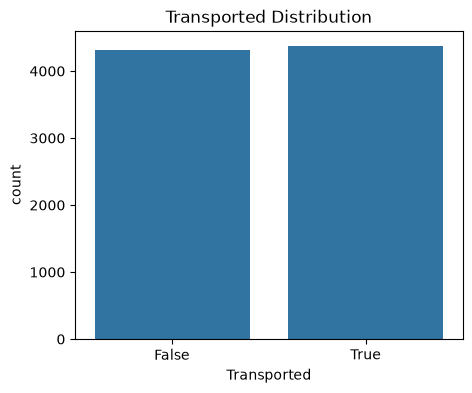

Transported
True     4378
False    4315
Name: count, dtype: int64


In [16]:
plt.figure(figsize=(5,4))

sns.countplot(data=train, x="Transported")

plt.title("Transported Distribution")
plt.show()

print(train["Transported"].value_counts())

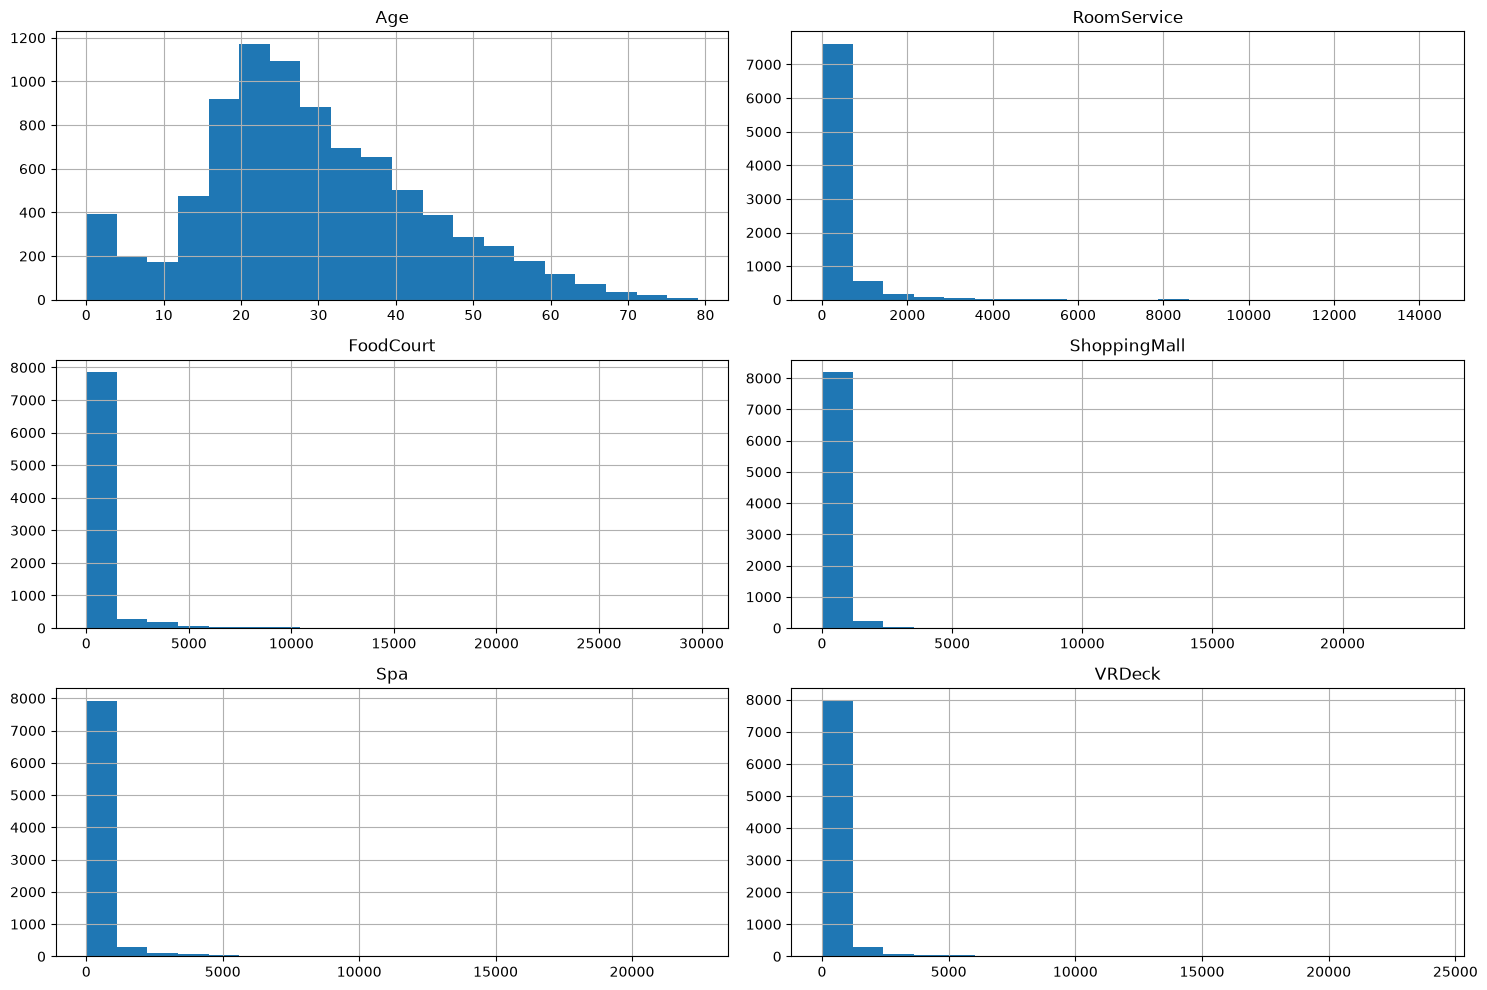

In [17]:
numeric_columns = train.select_dtypes(include=["int64", "float64"]).columns

train[numeric_columns].hist(figsize=(15,10), bins=20)

plt.tight_layout()
plt.show()

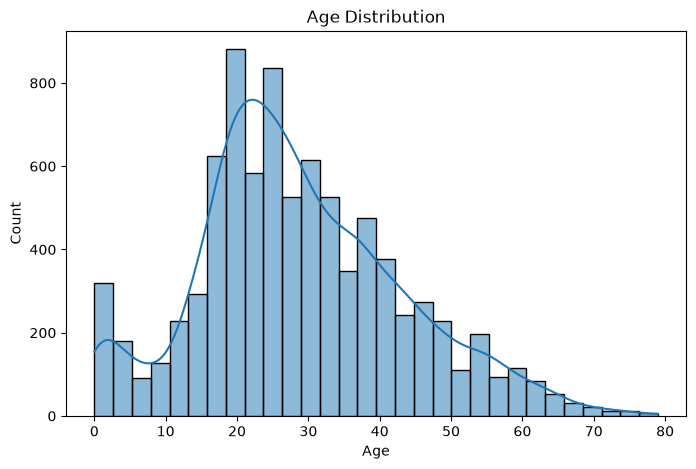

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(train["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")

plt.show()

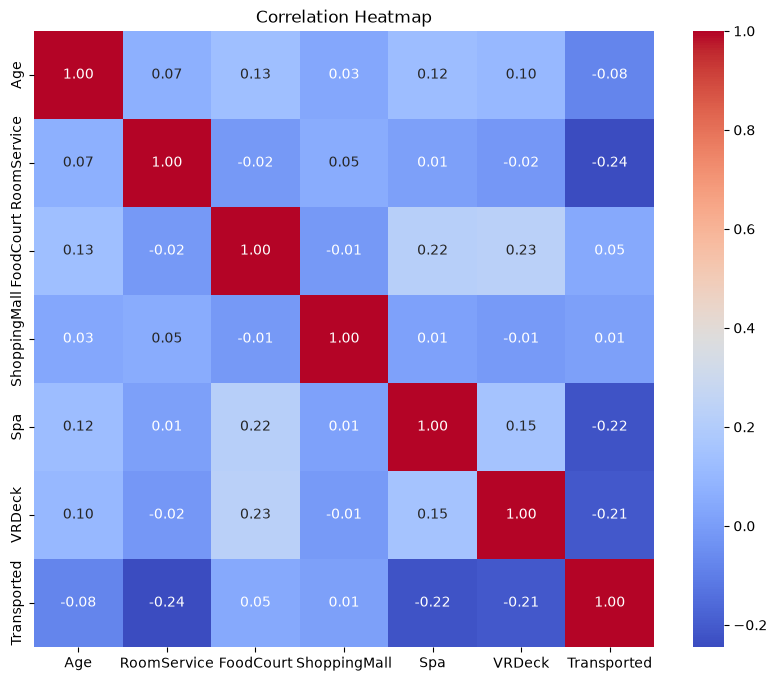

In [19]:
corr_train = train.copy()
corr_train["Transported"] = corr_train["Transported"].astype(int)

numeric_corr = corr_train.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_corr.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

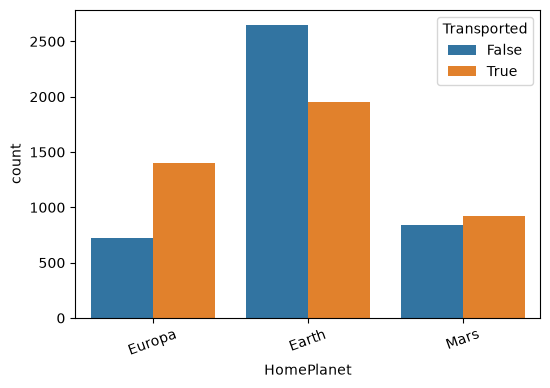

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train,
    x="HomePlanet",
    hue="Transported"
)

plt.xticks(rotation=20)
plt.show()

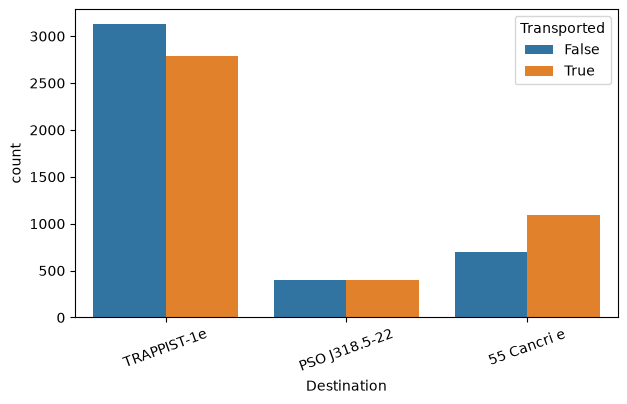

In [21]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=train,
    x="Destination",
    hue="Transported"
)

plt.xticks(rotation=20)
plt.show()

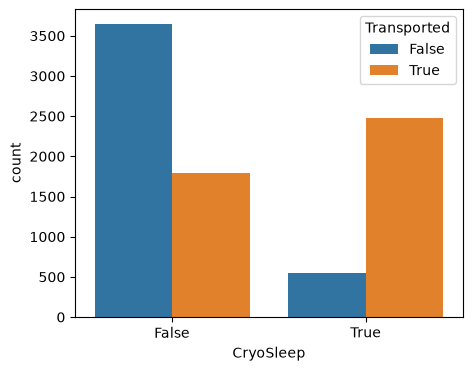

In [22]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=train,
    x="CryoSleep",
    hue="Transported"
)

plt.show()

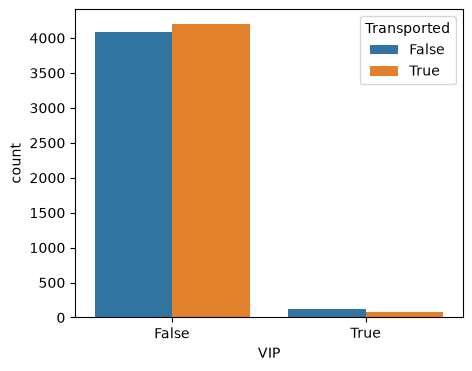

In [24]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=train,
    x="VIP",
    hue="Transported"
)

plt.show()

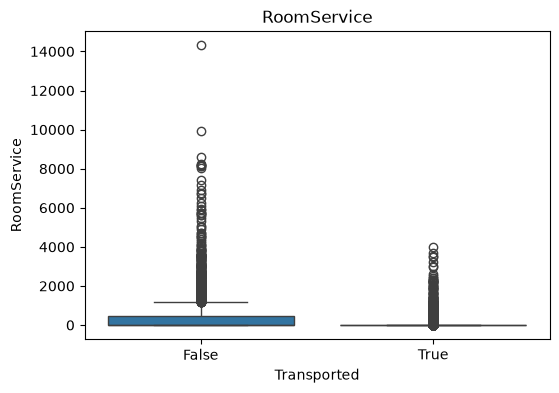

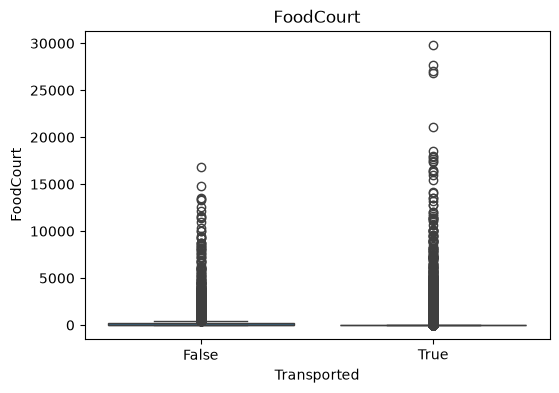

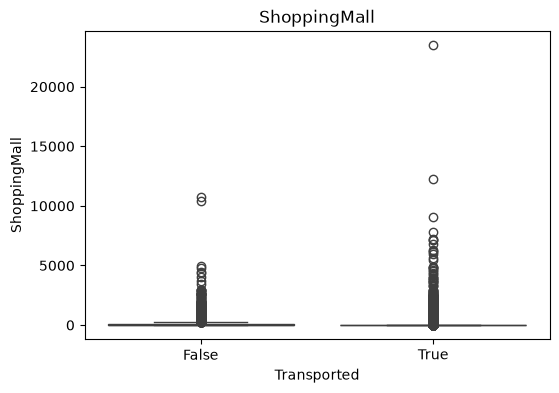

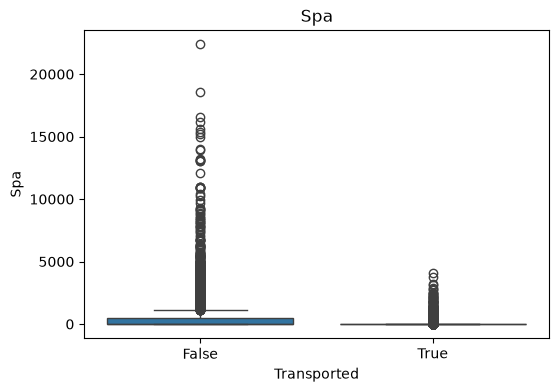

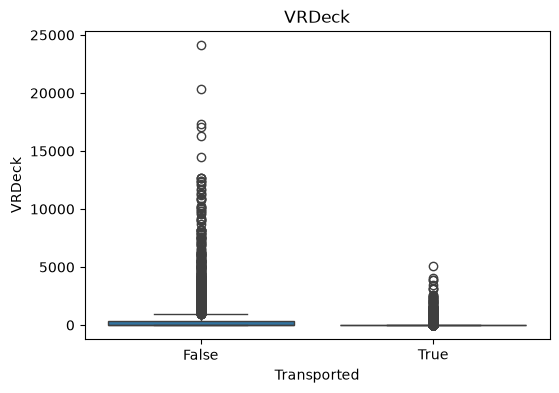

In [25]:
spending_cols = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

for col in spending_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=train, x="Transported", y=col)
    plt.title(col)
    plt.show()

In [26]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

display(train.head())

print("\nMissing Values:")
display(train.isnull().sum())

print("\nTarget Distribution:")
display(train["Transported"].value_counts())

Train Shape: (8693, 14)
Test Shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True



Missing Values:


PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


Target Distribution:


Transported
True     4378
False    4315
Name: count, dtype: int64

In [27]:
train_df = train.copy()
test_df = test.copy()

for df in [train_df, test_df]:
    df["Deck"] = df["Cabin"].str.split("/").str[0]
    df["CabinNum"] = df["Cabin"].str.split("/").str[1]
    df["Side"] = df["Cabin"].str.split("/").str[2]

for df in [train_df, test_df]:
    df["Group"] = df["PassengerId"].str.split("_").str[0]

spending_cols = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

for df in [train_df, test_df]:
    df["TotalSpend"] = df[spending_cols].fillna(0).sum(axis=1)

for df in [train_df, test_df]:
    df["NoSpending"] = (df["TotalSpend"] == 0).astype(int)

for df in [train_df, test_df]:
    df["FamilySize"] = df.groupby("Group")["Group"].transform("count")

print("Feature Engineering Completed")

Feature Engineering Completed


In [28]:
from sklearn.model_selection import train_test_split

X = train_df.drop("Transported", axis=1)
y = train_df["Transported"].astype(int)

X_test = test_df.copy()

drop_cols = ["PassengerId", "Name", "Cabin", "Group"]

X = X.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

cat_cols = X.select_dtypes(include=["object", "bool"]).columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical Columns:")
print(cat_cols)

print("\nNumerical Columns:")
print(num_cols)

Categorical Columns:
Index(['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'CabinNum',
       'Side'],
      dtype='str')

Numerical Columns:
Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'TotalSpend', 'NoSpending', 'FamilySize'],
      dtype='str')


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11476\1920221597.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "bool"]).columns


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [30]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_valid.shape)

(6954, 16)
(1739, 16)


 Model 1 - Random Forest

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)

print("Random Forest Accuracy:",
      accuracy_score(y_valid, rf_pred))

Random Forest Accuracy: 0.7941345600920069


In [33]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(classification_report(y_valid, rf_pred))

print(confusion_matrix(y_valid, rf_pred))

              precision    recall  f1-score   support

           0       0.77      0.83      0.80       863
           1       0.82      0.76      0.79       876

    accuracy                           0.79      1739
   macro avg       0.80      0.79      0.79      1739
weighted avg       0.80      0.79      0.79      1739

[[712 151]
 [207 669]]


Model 2 - XGBoost

In [34]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_valid)

print("XGBoost Accuracy:",
      accuracy_score(y_valid, xgb_pred))

XGBoost Accuracy: 0.8131109833237493


In [35]:
best_model = xgb_model

predictions = best_model.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": predictions.astype(bool)
})

submission.to_csv("../outputs/submission.csv", index=False)

submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [36]:
import joblib

joblib.dump(best_model, "../models/spaceship_titanic_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [37]:
print("Final Features Used:")
print(list(X.columns))

print("\nNumber of Features:", len(X.columns))

Final Features Used:
['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Deck', 'CabinNum', 'Side', 'TotalSpend', 'NoSpending', 'FamilySize']

Number of Features: 16


In [38]:
print("="*50)
print("SPACESHIP TITANIC PROJECT SUMMARY")
print("="*50)

print(f"Training Samples : {train.shape[0]}")
print(f"Test Samples     : {test.shape[0]}")
print(f"Features Used    : {len(X.columns)}")

print("\nModels Trained:")
print("- Random Forest")
print("- XGBoost")

print("\nFeature Engineering:")
print("- Deck")
print("- CabinNum")
print("- Side")
print("- Group")
print("- FamilySize")
print("- TotalSpend")
print("- NoSpending")

print("\nSubmission file generated successfully!")

SPACESHIP TITANIC PROJECT SUMMARY
Training Samples : 8693
Test Samples     : 4277
Features Used    : 16

Models Trained:
- Random Forest
- XGBoost

Feature Engineering:
- Deck
- CabinNum
- Side
- Group
- FamilySize
- TotalSpend
- NoSpending

Submission file generated successfully!


In [39]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss
)

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV Mean Accuracy :", cv_scores.mean())
print("CV Std :", cv_scores.std())

pred = best_model.predict(X_valid)
prob = best_model.predict_proba(X_valid)[:, 1]

print("Validation Accuracy :", accuracy_score(y_valid, pred))
print("Precision :", precision_score(y_valid, pred))
print("Recall :", recall_score(y_valid, pred))
print("F1 Score :", f1_score(y_valid, pred))
print("ROC-AUC :", roc_auc_score(y_valid, prob))
print("Log Loss :", log_loss(y_valid, prob))

CV Mean Accuracy : 0.8015664465974188
CV Std : 0.01047457235244614
Validation Accuracy : 0.8131109833237493
Precision : 0.8004362050163577
Recall : 0.8378995433789954
F1 Score : 0.8187395426659231
ROC-AUC : 0.8968806383170104
Log Loss : 0.3939953148365021


In [40]:
import time

start = time.time()

best_model.fit(X_train, y_train)

end = time.time()

print("Training Time:", round(end - start, 2), "seconds")

Training Time: 0.92 seconds


 Model 3 - CatBoost

In [41]:
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

cat_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        random_seed=42,
        verbose=0
    ))
])

cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict(X_valid)

print("CatBoost Accuracy:", accuracy_score(y_valid, cat_pred))

CatBoost Accuracy: 0.8033352501437608


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, cat_pred))

              precision    recall  f1-score   support

           0       0.82      0.78      0.80       863
           1       0.79      0.83      0.81       876

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739



In [43]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

In [44]:
param_grid = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [3, 4, 5, 6, 7],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.2]
}

 Hyperparameter Tuning

In [45]:
search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=20,          # Try 20 combinations
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 0.9, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can b

In [46]:
print("Best Parameters:")
print(search.best_params_)

print("\nBest CV Accuracy:")
print(search.best_score_)

Best Parameters:
{'model__subsample': 0.9, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 7, 'model__learning_rate': 0.05, 'model__gamma': 0.2, 'model__colsample_bytree': 1.0}

Best CV Accuracy:
0.8022737123026238


In [47]:
best_model = search.best_estimator_

pred = best_model.predict(X_valid)

from sklearn.metrics import accuracy_score

print("Validation Accuracy:",
      accuracy_score(y_valid, pred))

Validation Accuracy: 0.8154111558366878


In [48]:
best_model = search.best_estimator_

 Model Evaluation

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    classification_report
)

pred = best_model.predict(X_valid)
prob = best_model.predict_proba(X_valid)[:,1]

print("Accuracy :", accuracy_score(y_valid, pred))
print("Precision:", precision_score(y_valid, pred))
print("Recall   :", recall_score(y_valid, pred))
print("F1 Score :", f1_score(y_valid, pred))
print("ROC AUC  :", roc_auc_score(y_valid, prob))
print("Log Loss :", log_loss(y_valid, prob))

print("\nClassification Report")
print(classification_report(y_valid, pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, pred))

Accuracy : 0.8154111558366878
Precision: 0.8079911209766926
Recall   : 0.8310502283105022
F1 Score : 0.8193584693303321
ROC AUC  : 0.8953508521299279
Log Loss : 0.3971123695373535

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       863
           1       0.81      0.83      0.82       876

    accuracy                           0.82      1739
   macro avg       0.82      0.82      0.82      1739
weighted avg       0.82      0.82      0.82      1739


Confusion Matrix
[[690 173]
 [148 728]]


In [50]:
predictions = best_model.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": predictions.astype(bool)
})

submission.to_csv("../outputs/submission.csv", index=False)

submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [51]:
import os

print(os.getcwd())

c:\Users\Lenovo\Documents\ML Project_Payoda\Spaceship_Titanic_Project\notebook


 Kaggle Submission

In [52]:
submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [53]:
submission.to_csv("../outputs/submission.csv", index=False)

In [54]:
predictions = best_model.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": predictions.astype(bool)
})

submission.to_csv("../outputs/submission.csv", index=False)

print("submission.csv saved successfully!")
submission.head()

submission.csv saved successfully!


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [55]:
import os

print(os.path.abspath("../outputs/submission.csv"))

c:\Users\Lenovo\Documents\ML Project_Payoda\Spaceship_Titanic_Project\outputs\submission.csv


In [56]:
submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [57]:
best_model = search.best_estimator_

 Final Model Selection

Four machine learning models were evaluated:

- Random Forest
- XGBoost
- CatBoost
- Tuned XGBoost

The tuned XGBoost achieved the highest validation accuracy (81.54%), while the original XGBoost obtained the best Kaggle public score (0.80126). The final submission was selected based on overall model performance.